In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer/Salary Data.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer/Salary Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


In [6]:
df.isna().sum()
df = df.dropna()

print(df.shape)

(373, 6)


2 out of 375 rows are missing - negligible

# Univariate Analysis

In [7]:
print(df["Job Title"].nunique())

174


In [8]:
df['Salary'].skew()

np.float64(0.400578053273342)

Skew measures lean (left vs right), not the NUMBER of peaks. A low-skew distribution can still be multimodal — this is a completely different diagnostic than skew, and it's a strong signal that your data might actually be a MIX of distinct sub-populations, not one smooth group.

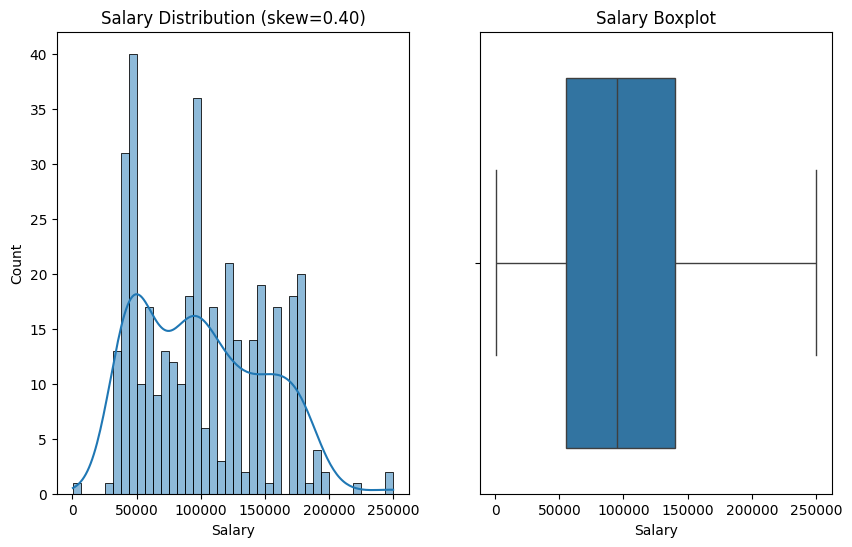

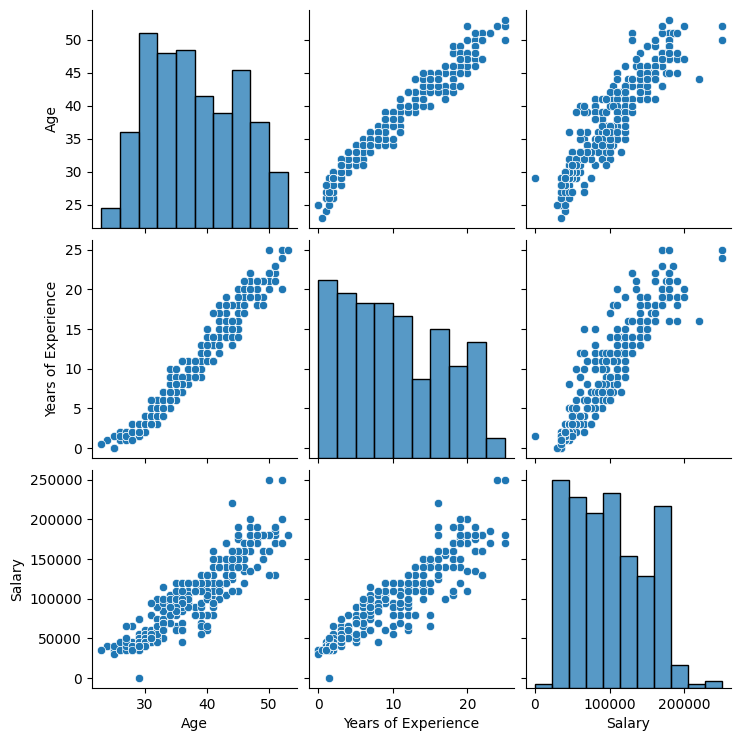

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
sns.histplot(df["Salary"], bins=40, kde=True, ax=ax[0])
ax[0].set_title(f"Salary Distribution (skew={df['Salary'].skew():.2f})")
sns.boxplot(x=df["Salary"], ax=ax[1])
ax[1].set_title("Salary Boxplot")
plt.show()

sns.pairplot(df)
plt.show()

This scatter looks fairly linear at first glance — there's no confirmed evidence yet that polynomial regression is needed here. That's exactly why we shouldn't assume it and must run the systematic check.

Multiple peaks in salary data usually mean distinct job categories or seniority levels are each forming their own salary cluster — for example: entry-level roles clustering around $40-60k, mid-level roles around $80-100k, and senior/director roles at $130k+. This directly ties back to Job Title (which we corrected from your initial "ordinal" label to "nominal" — it has no natural order) and Education Level, both of which likely explain these separate clusters.

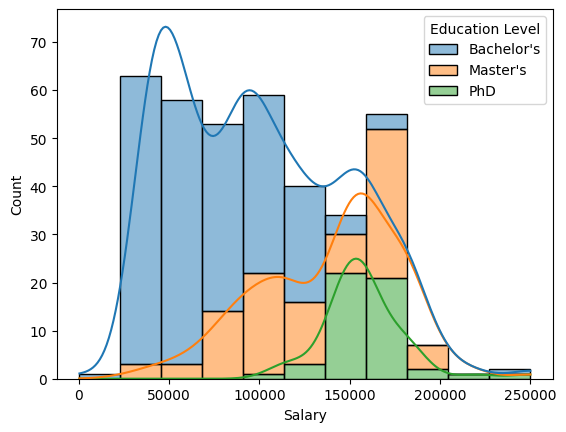

In [10]:
sns.histplot(data=df, x="Salary", hue="Education Level", kde=True, multiple="stack")
plt.show()

✅ Skew (0.4) — roughly symmetric, no log-transform needed
✅ Multimodality investigated — confirmed as genuine sub-population mixture (Education Level), not noise
⏭ Flag for later: possible Education × Experience interaction worth testing in Feature Engineering

# Model-Shape Check: Is the Years-of-Experience → Salary relationship linear?

## Step 1- Linear vs Quadratic Fit 

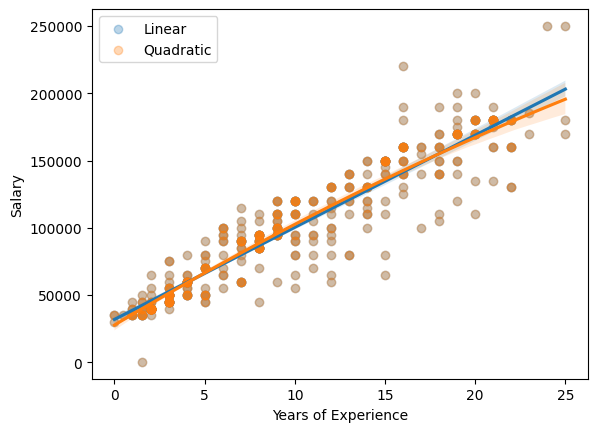

In [11]:
sns.regplot(x='Years of Experience', y="Salary", data=df, order=1, scatter_kws={'alpha':0.3}, label='Linear')
sns.regplot(x='Years of Experience', y="Salary", data=df, order=2, scatter_kws={'alpha':0.3}, label='Quadratic')
plt.legend()
plt.show()

## Step 2: Residual Plot

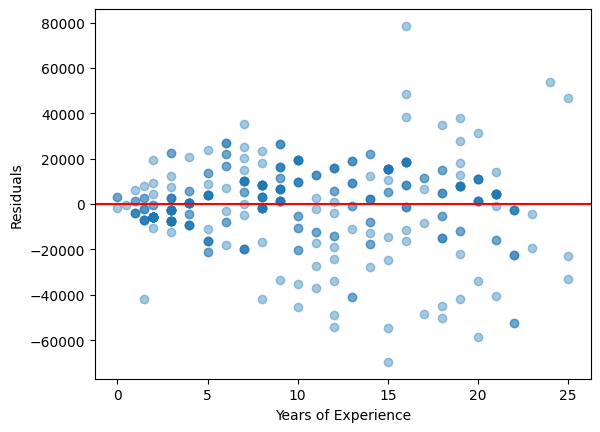

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[['Years of Experience']], df['Salary'])
predictions = model.predict(df[['Years of Experience']])
residuals = df['Salary'] - predictions

plt.scatter(df["Years of Experience"], residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel('Years of Experience')
plt.ylabel('Residuals')
plt.show()

Since regplot confirms linearity is fine, this is purely a variance-stability issue, not a shape issue — polynomial features wouldn't fix this. Worth revisiting whether log-transforming Salary (even with skew=0.4, "acceptable" by our threshold) might also stabilize this variance, since log-transforms sometimes help with heteroscedasticity even when skew alone doesn't demand it.

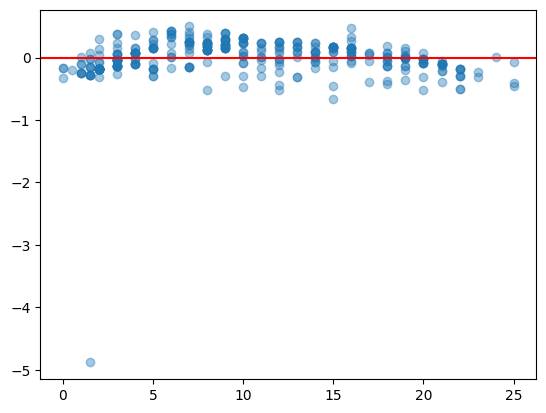

In [13]:
df["Salary_log"] = np.log1p(df["Salary"])
model_log = LinearRegression()
model_log.fit(df[["Years of Experience"]], df["Salary_log"])
residuals_log = df["Salary_log"] - model_log.predict(df[["Years of Experience"]])
plt.scatter(df["Years of Experience"], residuals_log, alpha=0.4)
plt.axhline(0, color="red")
plt.show()

Log-transforming Salary dramatically stabilized the variance — the funnel shape from the raw-scale residuals is essentially gone. This confirms that even though skew alone (0.4) suggested the log-transform was "optional," it was genuinely worth doing here for a different reason: fixing heteroscedasticity, not fixing skew.

# Investigating Outlier

A -4.9 log-residual is extreme — since log differences compound exponentially, this single point is roughly 134x off from prediction. This is very likely the same near-zero salary row visible in the pairplot earlier (bottom-left corner near Age~29, Salary~0) — worth investigating as a probable data error

In [14]:
df["residuals_log"] = df["Salary_log"] - model_log.predict(df[["Years of Experience"]])
df.sort_values("residuals_log").head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Salary_log,residuals_log
259,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,350.0,5.860786,-4.88303
116,40.0,Female,Bachelor's,Office Manager,15.0,65000.0,11.082158,-0.67124
52,40.0,Female,Bachelor's,Event Coordinator,12.0,60000.0,11.002117,-0.52693


A junior analyst earning $350/year is not a plausible real-world salary — comparing against similar-experience rows in the same dataset (which we'd expect to be $40-60k based on the pairplot's entry-level cluster) confirms this is almost certainly a data-entry error, not a genuine rare case

In [15]:
similar_rows = df[(df["Years of Experience"].between(1,2)) & (df["Job Title"].str.contains("Analyst"))]
similar_rows[["Age","Job Title","Years of Experience","Salary"]]

,Age,Job Title,Years of Experience,Salary
5,29.0,Marketing Analyst,2.0,55000.0
140,28.0,Junior Business Analyst,2.0,40000.0
189,28.0,Junior Operations Analyst,1.5,35000.0
195,28.0,Junior Business Analyst,2.0,40000.0
218,29.0,Junior Business Operations Analyst,1.5,35000.0
224,28.0,Junior Financial Analyst,2.0,40000.0
241,29.0,Junior Business Analyst,1.5,40000.0
259,29.0,Junior Business Operations Analyst,1.5,350.0
274,30.0,Junior Business Analyst,2.0,40000.0
324,29.0,Junior Marketing Analyst,2.0,40000.0


Row 218 is essentially a perfect twin of row 259 — same age, same exact job title, same experience — with a salary of $35,000. This confirms beyond doubt that $350 is a data-entry error, almost certainly missing two zeros, not a genuine data point. This is the strongest possible cross-check: an identical-profile row in the same dataset.

In [16]:
df = df.drop(index=259)
print(df.shape)

(372, 8)


Since only one row is affected and the correct value can only be guessed (not verified), dropping remains the safer choice over imputing a "corrected" value — even though the twin-row comparison strongly suggests what the true value likely was.

# Bivariate Analysis

## Numeric features vs Salary_log

In [17]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Salary', 'Salary_log', 'residuals_log']]

correlations = df[numeric_cols + ["Salary_log"]].corr()["Salary_log"].sort_values(ascending=False)
print(correlations)

Salary_log             1.000000
Age                    0.915962
Years of Experience    0.914462
Name: Salary_log, dtype: float64


In [18]:
print(df[["Age","Years of Experience"]].corr())

                          Age  Years of Experience
Age                  1.000000             0.979056
Years of Experience  0.979056             1.000000


Between two nearly-equally-correlated, highly redundant features, domain reasoning breaks the tie: Years of Experience is the more direct, causally-meaningful driver of salary, while Age is essentially a proxy for experience (correlated with it, but not the actual mechanism).

## Categorical features vs Salary_log

In [19]:
df["Job Title"].nunique()

174

174 categories on only 373 rows means most job titles appear just once or twice — nowhere near enough samples for reliable one-hot encoding. Education Level already captures much of the seniority/skill-level signal that Job Title would have carried.

In [20]:
df = df.drop(columns=["Job Title"])

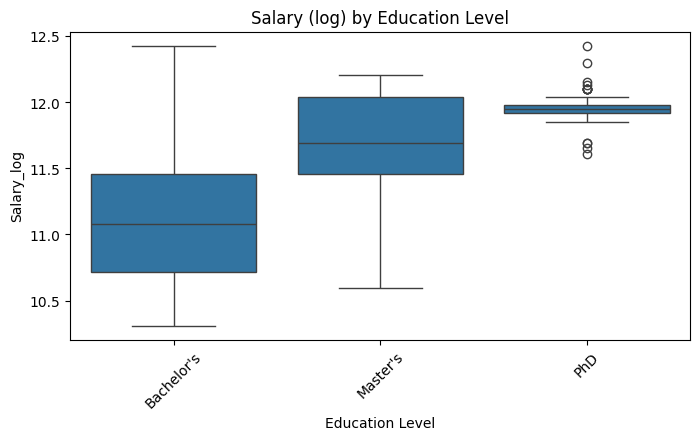

Education Level: F=136.150, p=0.0000


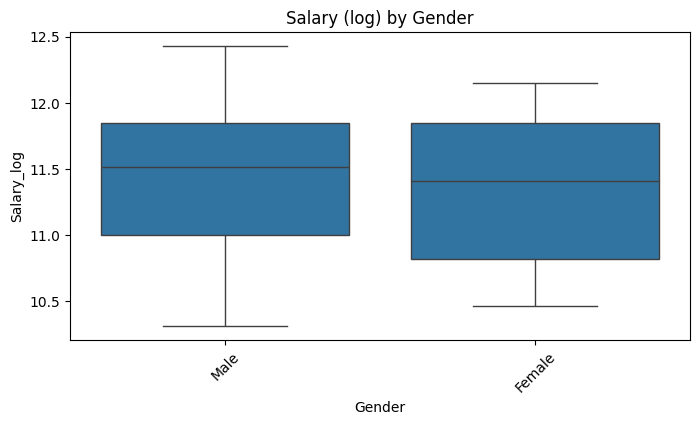

Gender: F=1.655, p=0.1991


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

for col in ["Education Level", "Gender"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y="Salary_log", data=df)
    plt.title(f"Salary (log) by {col}")
    plt.xticks(rotation=45)
    plt.show()

    groups = [g["Salary_log"].values for _, g in df.groupby(col)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.3f}, p={p_value:.4f}")

Hypothesis for each: H0 — the categorical variable has no real effect on Salary_log (differences are random noise). H1 — at least one category's average salary genuinely differs. Given the pairplot already showed Education Level forming distinct salary clusters, I'd expect an extremely high F-statistic here

F=136.15 with p≈0 confirms Education Level's effect on salary is overwhelmingly real, not random noise — this matches exactly what the pairplot visually suggested (three distinct, well-separated salary clusters by degree).

p > 0.05 → fail to reject H0 → any difference in average Salary across genders in this sample is statistically indistinguishable from random sampling noise.

# Feature Selection

# Feature Engineering